# 1. El Objetivo de Modelado

El objetivo es construir un motor cuantitativo de recomendación de acciones y portafolios para el mercado de Estados Unidos, usando:

- Series de tiempo de precios diarios de las acciones más líquidas.
- **Features técnicas** (momentum, volatilidad, RSI, distancias a medias móviles, etc.).
- Modelos de **aprendizaje automático supervisado** (Elastic Net, Random Forest, XGBoost).
- Un módulo de **optimización de portafolios tipo Markowitz** para asignar pesos según el perfil de riesgo del usuario.

La idea no es “adivinar exactamente el retorno futuro”, sino:

1. Aprender patrones históricos que permitan **ordenar** las acciones según su atractivo esperado.
2. Utilizar ese ranking para construir portafolios que, en backtests, se comporten **mejor que un portafolio promedio de mercado**, respetando el riesgo.
3. Traducir estos resultados a algo utilizable en una app, donde el usuario pueda ver **qué acciones y con qué pesos** tendría sentido invertir según su perfil de riesgo.


## Librerias

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 2. Carga y preparación básica de los datos

Primero cargamos el dataset ya preprocesado `datos_preprocesados_finales.csv`, que contiene:

- Precios de cierre diarios por acción (`Close`).
- Identificador de la acción (`Ticker`).
- Indicadores técnicos calculados por día y por acción.

Convertimos la columna `Date` a tipo fecha y ordenamos el panel por `Date` y `Ticker`.  
Con esto garantizamos que:

- Las operaciones de `groupby` por acción respeten el orden temporal.
- Más adelante podamos hacer particiones de entrenamiento y prueba sin romper la estructura de serie de tiempo.

In [90]:
df_ml = pd.read_csv(r"D:\\Datases_CD\\7mo\\Aprendizaje_Automatico\\Proyecto\\datos_preprocesados_finales.csv")
df_ml.head()

,Date,Close,Ticker,Return,ret_1d,ret_5d,ret_20d,vol_5d,vol_20d,ma_5,ma_20,dist_ma_5,dist_ma_20,ma_60,dist_ma_60,rsi_14,stoch_k_14,spy_ret_20d,excess_ret_20d_vs_spy
0,1996-02-22,0.223996,AAPL,0.008438,0.008438,0.081447,-0.073642,0.026105,0.031870,0.215936,0.214975,0.037325,0.041961,0.245271,-0.086741,59.677785,100.000000,0.067878,-0.141520
1,1996-02-23,0.223996,AAPL,0.000000,0.000000,0.066964,-0.012396,0.027113,0.028721,0.218747,0.214834,0.023992,0.042643,0.244005,-0.082006,54.545276,100.000000,0.068625,-0.081021
2,1996-02-26,0.221184,AAPL,-0.012552,-0.012552,0.072726,-0.036736,0.025652,0.028686,0.221746,0.214413,-0.002536,0.031581,0.242787,-0.088979,51.724017,84.211103,0.044438,-0.081175
3,1996-02-27,0.214623,AAPL,-0.029662,-0.029662,-0.012934,-0.017170,0.019641,0.027293,0.221184,0.214225,-0.029662,0.001858,0.241600,-0.111658,43.547968,47.366523,0.037010,-0.054180
4,1996-02-28,0.208063,AAPL,-0.030566,-0.030566,-0.063291,0.016017,0.017428,0.024276,0.218372,0.214389,-0.047209,-0.029508,0.240366,-0.134390,46.551829,10.525959,0.023556,-0.007539


In [91]:
df_work = df_ml.copy()
# Aseguramos tipo datetime y orden temporal
df_work["Date"] = pd.to_datetime(df_work["Date"])
df_work = df_work.sort_values(["Date", "Ticker"]).reset_index(drop=True)

# 3. Definición de la variable objetivo: retorno a 20 días

Definimos como objetivo de predicción el **retorno a 20 días** de cada acción:

$$
y_{t}^{20d} \;=\; \frac{P_{t+20} - P\_{t}}{P_{t}},
$$

donde $P_t$ es el precio de cierre en el día $t$.  
Elegimos un horizonte de 20 días (aprox. un mes bursátil) porque:

- Es lo suficientemente corto para captar efectos de **momentum** y señales técnicas.
- Es más estable que horizontes muy cortos (por ejemplo 1 o 5 días), donde los retornos son casi ruido puro.

Eliminamos las filas donde no existe $P_{t+20}$ (últimos 20 días de cada acción) para evitar objetivos indefinidos.


In [92]:
df_work["Close_future_20d"] = df_work.groupby("Ticker")["Close"].shift(-20)
df_work["y_20d"] = (df_work["Close_future_20d"] - df_work["Close"]) / df_work["Close"]
df_work = df_work.dropna(subset=["y_20d"])

# 4. Features técnicas utilizadas

Seleccionamos como variables explicativas un conjunto de **indicadores técnicos**, calculados por acción y por día:

- $ret_{5d}$, $ret_{20d}$: retornos acumulados a 5 y 20 días.
- $vol_{5d}$, $vol_{20d}$: volatilidad (desviación estándar) de retornos a 5 y 20 días.
- $dist_{ma20}$, $dist_{ma60}$: distancia relativa entre el precio actual y la media móvil de 20 y 60 días.
- $rsi_{14}$: índice de fuerza relativa a 14 días.
- $stoch_{k14}$: oscilador estocástico %K a 14 días.
- $excessret_{20d\_vs\_spy}$: exceso de retorno a 20 días de la acción frente al ETF del índice ($SPY$).

Estas features capturan información de **tendencia (momentum)**, **volatilidad**, **sobrecompra/sobreventa** y **relación frente al mercado**, que son señales que sirven en modelos de selección de acciones.

Finalmente, eliminamos filas con valores faltantes en cualquiera de estas columnas o en $y_{20d}$ para entrenar los modelos con datos consistentes.


In [93]:
feature_cols = [
    "ret_5d",
    "ret_20d",
    "vol_5d",
    "vol_20d",
    "dist_ma_20",
    "dist_ma_60",
    "rsi_14",
    "stoch_k_14",
    "excess_ret_20d_vs_spy",
]

df_ml = df_work.dropna(subset=feature_cols + ["y_20d"]).reset_index(drop=True)

print("Shape después de limpieza:", df_ml.shape)

Shape después de limpieza: (763136, 21)


# 5. Control de outliers en el objetivo

Los retornos a 20 días pueden contener **outliers extremos** debido a:

- Splits, fusiones o eventos corporativos.
- Errores de datos o movimientos excepcionales.

Para evitar que estos episodios dominen el entrenamiento y el backtest, recortamos $y_{20d}$ al rango:

$$
-50\% \;\leq\; y_{20d} \;\leq\; 50\%.
$$

Este recorte mantiene la mayoría de los movimientos reales de mercado, pero limita el impacto de valores anómalos que podrían llevar a conclusiones irreales en los portafolios simulados.


In [94]:
horizon_col = "y_20d"   

# Recortamos (clip) retornos a [-50%, +50%] en el horizonte
df_ml[horizon_col] = df_ml[horizon_col].clip(-0.5, 0.5)


# 6. Partición temporal de entrenamiento y prueba (90/10)

Para evaluar modelos de series de tiempo necesitamos evitar fuga de información del futuro.  
En lugar de hacer un `train_test_split` aleatorio, ordenamos todas las fechas y definimos:

- **Train (90 % inicial de fechas):** usado para ajustar y validar modelos.
- **Test (10 % final de fechas):** bloque más reciente, que representa el comportamiento fuera de muestra.

De esta forma, los modelos sólo “ven” el pasado y se evalúan en un periodo posterior.


In [95]:
all_dates = np.sort(df_ml["Date"].unique())
split_idx = int(len(all_dates) * 0.9)
fecha_split = all_dates[split_idx]

print("Fecha de corte 90/10:", fecha_split)

train_mask = df_ml["Date"] <= fecha_split
test_mask  = df_ml["Date"] > fecha_split

df_train = df_ml[train_mask].copy()
df_test  = df_ml[test_mask].copy()

print("Shape train:", df_train.shape)
print("Shape test :", df_test.shape)

X_train = df_train[feature_cols].values
y_train = df_train["y_20d"].values

X_test  = df_test[feature_cols].values
y_test  = df_test["y_20d"].values

Fecha de corte 90/10: 2022-10-27T00:00:00.000000000
Shape train: (677017, 21)
Shape test : (86119, 21)


# 7. Validación cruzada temporal

Dentro del bloque de entrenamiento (90 % inicial) utilizamos `TimeSeriesSplit` para hacer **validación cruzada temporal**:

- Cada fold usa un tramo inicial como entrenamiento y un bloque posterior como validación.
- Se respeta el orden temporal: nunca se entrena con datos posteriores a los usados para validar.

Esto permite estimar la estabilidad del modelo a lo largo del tiempo, sin afectar la estructura de serie de tiempo.


In [97]:
tscv = TimeSeriesSplit(n_splits=3)  # 3 folds temporales sobre el train

# 8. Modelo 1: Elastic Net (regresión lineal regularizada)

Como baseline lineal utilizamos **Elastic Net**, que combina regularización $L1$ (tipo Lasso) y $L2$ (tipo Ridge):

$$
\min_{w} \; \frac{1}{2n} \sum\_{i} (y_i - x_i^\top w)^2
\;+\; \alpha \Big( \, \lambda \lVert w \rVert\_1 + (1-\lambda) \lVert w \rVert_2^2 \Big).
$$

Para poder : 

- Tener un punto de partida interpretable.
- Controla el sobreajuste en presencia de features correlacionadas.
- Permite comparar el valor añadido de modelos no lineales (Random Forest, XGBoost).


In [98]:
pipe_en = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(
        alpha=0.01,        
        l1_ratio=0.5,      # mezcla L1/L2
        max_iter=10000,
        random_state=0
    )),
])

scores_en = cross_validate(
    pipe_en,
    X_train,
    y_train,
    cv=tscv,
    scoring={
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    },
    n_jobs=-1,
    return_train_score=False
)

print("\n=== ElasticNet: CV temporal (train 90%) ===")
print("MAE_cv_mean:", -scores_en["test_mae"].mean())
print("MAE_cv_std :",  scores_en["test_mae"].std())
print("R2_cv_mean :",  scores_en["test_r2"].mean())
print("R2_cv_std  :",  scores_en["test_r2"].std())

# Entrenamos ElasticNet final con TODO el train (90%)
pipe_en.fit(X_train, y_train)

y_pred_en = pipe_en.predict(X_test)
mae_en = mean_absolute_error(y_test, y_pred_en)
r2_en  = r2_score(y_test, y_pred_en)

print("\n=== ElasticNet: desempeño en test (10% más reciente) ===")
print("MAE_test:", mae_en)
print("R2_test :", r2_en)


=== ElasticNet: CV temporal (train 90%) ===
MAE_cv_mean: 0.05745675552240379
MAE_cv_std : 0.005797750921247797
R2_cv_mean : -0.002038843419601403
R2_cv_std  : 0.0027192765641564057

=== ElasticNet: desempeño en test (10% más reciente) ===
MAE_test: 0.05919356931567958
R2_test : -0.004806341259830482


# 9. Modelo 2: Random Forest Regressor

El segundo modelo es un Random Forest, un ensamble de muchos árboles de decisión entrenados sobre subconjuntos de datos y features:

- Captura **relaciones no lineales** y **interacciones** entre indicadores técnicos.
- Es robusto al ruido y a la escala de las variables.
- Los hiperparámetros se fijan en valores razonables (por ejemplo, `n_estimators = 200`, `max_depth = 8`) para equilibrar capacidad y coste computacional.

In [99]:


rf = RandomForestRegressor(
    n_estimators=200,      
    max_depth=8,       
    min_samples_split=5,
    min_samples_leaf=3,
    max_features="sqrt",
    criterion="squared_error",
    random_state=0,
    n_jobs=-1
)

# CV temporal
scores_rf = cross_validate(
    rf,
    X_train,
    y_train,
    cv=tscv,
    scoring={
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    },
    n_jobs=-1,
    return_train_score=False
)

print("\n=== RandomForest: CV temporal (train 90%) ===")
print("MAE_cv_mean:", -scores_rf["test_mae"].mean())
print("MAE_cv_std :",  scores_rf["test_mae"].std())
print("R2_cv_mean :",  scores_rf["test_r2"].mean())
print("R2_cv_std  :",  scores_rf["test_r2"].std())

# Entrenamos RF final con TODO el train (90%)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf  = r2_score(y_test, y_pred_rf)

print("\n=== RandomForest: desempeño en test (10% más reciente) ===")
print("MAE_test:", mae_rf)
print("R2_test :", r2_rf)



=== RandomForest: CV temporal (train 90%) ===
MAE_cv_mean: 0.057478406630193775
MAE_cv_std : 0.005882976991528382
R2_cv_mean : -0.0051876940417570445
R2_cv_std  : 0.00936508969123937

=== RandomForest: desempeño en test (10% más reciente) ===
MAE_test: 0.059012628055594304
R2_test : 0.0030797042978605305


# 10. Modelo 3: XGBoost Regressor

El tercer modelo es **XGBoost**, un algoritmo de gradient boosting basado en árboles que ajusta sucesivos árboles para corregir los errores del modelo anterior:

- Suele funcionar muy bien en datos tabulares con relaciones no lineales.
- Incluye regularización explícita y parámetros de control de complejidad (profundidad máxima, número de árboles, `learning_rate`, etc.).
- Usamos una configuración moderada (por ejemplo, `n_estimators = 250`, `max_depth = 5`, `learning_rate = 0.05`) para obtener un balance entre rendimiento y estabilidad.

In [100]:
xgb = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",    
    n_estimators=250,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_lambda=1.0,
    reg_alpha=0.0,
    eval_metric="mae",
    random_state=0,
    n_jobs=-1
)

# CV temporal
scores_xgb = cross_validate(
    xgb,
    X_train,
    y_train,
    cv=tscv,
    scoring={
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    },
    n_jobs=1,             
    return_train_score=False
)

print("\n=== XGBoost: CV temporal (train 90%) ===")
print("MAE_cv_mean:", -scores_xgb["test_mae"].mean())
print("MAE_cv_std :",  scores_xgb["test_mae"].std())
print("R2_cv_mean :",  scores_xgb["test_r2"].mean())
print("R2_cv_std  :",  scores_xgb["test_r2"].std())

# Entrenamos XGB final con TODO el train (90%)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb  = r2_score(y_test, y_pred_xgb)

print("\n=== XGBoost: desempeño en test (10% más reciente) ===")
print("MAE_test:", mae_xgb)
print("R2_test :", r2_xgb)


=== XGBoost: CV temporal (train 90%) ===
MAE_cv_mean: 0.05791459745911845
MAE_cv_std : 0.006174318792889662
R2_cv_mean : -0.029019078186159602
R2_cv_std  : 0.02413562426848356

=== XGBoost: desempeño en test (10% más reciente) ===
MAE_test: 0.0591026575204655
R2_test : 0.0007414761906842093


# 11. Comparación de modelos en el bloque de prueba

Una vez entrenados los tres modelos sobre el 90 % inicial de fechas, evaluamos su desempeño en el **10 % más reciente**:

- Métrica principal: **MAE** (error absoluto medio) del retorno a 20 días.
- Métrica secundaria: **$R^2$**, que mide cuánto mejora el modelo frente a predecir un retorno constante.

En problemas financieros es habitual obtener valores de $R^2$ cercanos a cero, ya que los retornos contienen mucho ruido.  
Sin embargo, incluso con $R^2$ bajo, los modelos pueden aportar valor si:

- Capturan **la dirección** del movimiento con probabilidad ligeramente superior al 50 %.
- Permiten construir portafolios que, en conjunto, tienen mejor desempeño que el mercado.


In [101]:
resultados_test = pd.DataFrame({
    "ElasticNet":   {"MAE_test": mae_en,  "R2_test": r2_en},
    "RandomForest": {"MAE_test": mae_rf,  "R2_test": r2_rf},
    "XGBoost":      {"MAE_test": mae_xgb, "R2_test": r2_xgb},
}).T.sort_values("MAE_test")

print("\n=== Comparación final en test (ordenado por MAE) ===")
print(resultados_test)


=== Comparación final en test (ordenado por MAE) ===
              MAE_test   R2_test
RandomForest  0.059013  0.003080
XGBoost       0.059103  0.000741
ElasticNet    0.059194 -0.004806


# 12. Acierto direccional del Random Forest

Aunque el Random Forest no predice con precisión el valor exacto de $y_{20d}$, evaluamos su capacidad para acertar **el signo del retorno** (sube/baja):

$$
\text{acierto direccional} =
\frac{1}{N} \sum_{i} \mathbf{1}\big( \text{sign}(y_i) = \text{sign}(\hat{y}_i) \big).
$$

En el bloque de prueba obtenemos un acierto direccional cercano al $60\%$, superior al $50\%$ que correspondería a una decisión aleatoria.  
Esta pequeña ventaja estadística es suficiente para que, usada correctamente en portafolios, pueda traducirse en una mejora de rendimiento frente al mercado.


In [102]:
# X_test desde df_test 
X_test = df_test[feature_cols].values
y_test = df_test[horizon_col].values

# Predicciones del RF
y_pred_rf = rf.predict(X_test)

# df_eval con todo lo necesario
df_eval = df_test.copy()
df_eval["y_pred_rf"] = y_pred_rf
df_eval["y_real"] = df_eval[horizon_col]

# Recorte de outliers solo para el backtest
df_eval["y_real"] = df_eval["y_real"].clip(-0.5, 0.5)

# Acierto direccional global
df_eval["direction_correct"] = np.sign(df_eval["y_pred_rf"]) == np.sign(df_eval["y_real"])
print("Acierto direccional RF:", df_eval["direction_correct"].mean())

mae_rf = mean_absolute_error(df_eval["y_real"], df_eval["y_pred_rf"])
r2_rf  = r2_score(df_eval["y_real"], df_eval["y_pred_rf"])
print("MAE_test RF:", mae_rf)
print("R2_test RF :", r2_rf)

df_eval.head()

Acierto direccional RF: 0.5993567040954958
MAE_test RF: 0.059012628055594304
R2_test RF : 0.0030797042978605305


,Date,Close,Ticker,Return,ret_1d,ret_5d,ret_20d,vol_5d,vol_20d,ma_5,...,dist_ma_60,rsi_14,stoch_k_14,spy_ret_20d,excess_ret_20d_vs_spy,Close_future_20d,y_20d,y_pred_rf,y_real,direction_correct
677017,2022-10-28,153.171341,AAPL,0.075553,0.075553,0.057514,0.126918,0.041546,0.026943,147.856433,...,0.005867,67.128798,100.000000,0.089143,0.037775,142.076584,-0.072434,0.013280,-0.072434,False
677018,2022-10-28,132.250687,ABBV,-0.038371,-0.038371,0.003740,0.111035,0.025300,0.019148,135.167883,...,0.051292,67.256876,60.549255,0.089143,0.021892,141.944824,0.073301,0.012817,0.073301,True
677019,2022-10-28,93.851982,ABT,0.026411,0.026411,0.046602,0.033066,0.020507,0.024813,92.650191,...,-0.035350,47.975830,44.657128,0.089143,-0.056077,99.417656,0.059303,0.015997,0.059303,True
677020,2022-10-28,274.873138,ACN,0.032062,0.032062,0.067552,0.123435,0.015761,0.021755,267.902448,...,0.021219,75.086611,100.000000,0.089143,0.034292,277.566589,0.009799,0.011947,0.009799,True
677021,2022-10-28,325.679993,ADBE,0.022062,0.022062,0.063028,0.183430,0.019081,0.019334,320.964001,...,-0.060465,79.972989,100.000000,0.089143,0.094287,328.970001,0.010102,0.014439,0.010102,True


# 13. De predicción individual a portafolios: Markowitz + ML

Para que el modelo sea útil en una app, no basta con predecir retornos individuales:  
el usuario necesita ver **portafolios completos** que equilibren retorno y riesgo.

Usamos las predicciones del Random Forest como vector de **retornos esperados** $\mu$ y la covarianza histórica de los retornos diarios como matriz de **riesgo** $\Sigma$.  
Sobre un subconjunto de acciones (top $X\%$ por score del modelo), resolvemos un problema de **optimización de media–varianza** tipo Markowitz, con restricciones long-only:

$$
\max_w \; w^\top \mu - \lambda \, w^\top \Sigma w
\quad \text{s.a.} \quad
\sum_i w_i = 1, \; w_i \ge 0.
$$

donde $w$ son los pesos del portafolio y $\lambda$ controla la aversión al riesgo.

En el backtest:

- Rebalanceamos el portafolio cada $20$ días (mismo horizonte que $y_{20d}$).
- Comparamos tres estrategias:
  1. **Portafolio Markowitz (ML + riesgo)**.
  2. **Top $X\%$ equiponderado** (ranking del modelo sin optimización).
  3. **Mercado** (promedio de todas las acciones).

Esto permite medir si la combinación de ML + optimización de portafolios aporta valor sobre una estrategia de mercado pasiva.

In [104]:

def markowitz_long_only(mu, Sigma, risk_aversion=10.0):
    """
    mu: vector de retornos esperados (por ejemplo, predicciones del modelo) de tamaño n
    Sigma: matriz de covarianza (n x n)
    risk_aversion: λ en w^T mu - λ w^T Σ w
    """
    n = len(mu)
    mu = np.asarray(mu)
    Sigma = np.asarray(Sigma)

    def obj(w):
        return -(w @ mu - risk_aversion * (w @ Sigma @ w))

    cons = ({"type": "eq", "fun": lambda w: np.sum(w) - 1.0},)
    bounds = [(0.0, 1.0)] * n
    w0 = np.full(n, 1.0 / n)

    res = minimize(obj, w0, bounds=bounds, constraints=cons)

    if not res.success:
        return w0
    return res.x


In [ ]:
# Config
horizon_col   = "y_20d"   
horizon_days  = 20       
top_frac      = 0.2       # top 20% por score
lookback_days = 60        # ventana para covarianza de retornos diarios
risk_aversion = 10.0

df_all = df_ml.copy()
df_all["Date"] = pd.to_datetime(df_all["Date"])

df_eval_bt = df_eval.copy()
df_eval_bt["Date"] = pd.to_datetime(df_eval_bt["Date"])

# Fechas de test y fechas de rebalanceo sin solapamiento
dates_test = sorted(df_eval_bt["Date"].unique())
rebalance_dates = dates_test[::horizon_days]  # una cada 20 días aprox

resultados_markowitz = []

for fecha in rebalance_dates:
    grupo = df_eval_bt[df_eval_bt["Date"] == fecha].copy()
    if len(grupo) < 5:
        continue

    grupo = grupo.sort_values("y_pred_rf", ascending=False)

    # 1) Universo: top X% por score
    k = max(3, int(len(grupo) * top_frac))
    top = grupo.head(k).copy()
    tickers_top = top["Ticker"].unique()

    # 2) Estimamos covarianza con retornos diarios últimos N días
    fecha_inicio_lb = fecha - pd.Timedelta(days=lookback_days)
    df_hist = df_all[
        (df_all["Date"] < fecha) &
        (df_all["Date"] >= fecha_inicio_lb) &
        (df_all["Ticker"].isin(tickers_top))
    ].copy()

    ret_mat = df_hist.pivot(index="Date", columns="Ticker", values="Return")
    # Columnas con al menos el 70% de datos
    min_non_na = int(lookback_days * 0.7)
    ret_mat = ret_mat.dropna(axis=1, thresh=min_non_na)

    if ret_mat.shape[1] < 3:
        # Muy pocos activos con historia decente: equiponderado del top
        tickers_final = top["Ticker"].unique()
        w_mark = np.full(len(tickers_final), 1.0 / len(tickers_final))
    else:
        tickers_final = ret_mat.columns
        Sigma = ret_mat.cov().values

        # mu: predicciones del modelo para estos tickers en la fecha
        mu_vec = (
            top.set_index("Ticker")
               .reindex(tickers_final)["y_pred_rf"]
               .values
        )

        # rellenar NaNs con la media de mu
        mu_mean = np.nanmean(mu_vec)
        mu_vec = np.where(np.isnan(mu_vec), mu_mean, mu_vec)

        # Resolver Markowitz
        w_mark = markowitz_long_only(mu_vec, Sigma, risk_aversion=risk_aversion)

    # 3) Retorno REAL a horizonte (ya está en y_real / y_20d en la fila de esa fecha)
    sub_real = (
        grupo.set_index("Ticker")
             .reindex(tickers_final)["y_real"]
    )
    y_real_vec = sub_real.values

    # Ajustamos por posibles NaNs
    valid_mask = ~np.isnan(y_real_vec)
    if valid_mask.sum() < 1:
        continue

    w_valid = w_mark[valid_mask]
    w_valid = w_valid / w_valid.sum()
    y_valid = y_real_vec[valid_mask]

    port_ret_mark = np.dot(w_valid, y_valid)

    # 4) Portafolio top X% equiponderado (sin Markowitz)
    port_ret_equal = top["y_real"].mean()

    # 5) “Mercado”: promedio de todas las acciones ese día
    mkt_ret = grupo["y_real"].mean()

    resultados_markowitz.append({
        "Date": fecha,
        "port_markowitz": port_ret_mark,
        "port_equal_top": port_ret_equal,
        "mkt_ret": mkt_ret,
        "n_top": len(tickers_top),
        "n_markowitz": len(tickers_final),
    })

df_mark_bt = pd.DataFrame(resultados_markowitz).sort_values("Date").reset_index(drop=True)
df_mark_bt.head()

,Date,port_markowitz,port_equal_top,mkt_ret,n_top,n_markowitz
0,2022-10-28,0.080143,0.040843,0.030844,23,23
1,2022-11-28,-0.078777,-0.078777,-0.031932,23,23
2,2022-12-27,0.170037,0.170037,0.073038,23,23
3,2023-01-26,-0.006562,-0.006562,-0.021256,23,23
4,2023-02-24,0.039309,0.039309,0.003832,23,23


# 14. Métricas de riesgo–retorno para la app

Además del retorno acumulado, calculamos métricas clásicas de gestión de portafolios:

- **Retorno total** y **retorno anualizado**.
- **Volatilidad anualizada**.
- **Ratio de Sharpe** (retorno ajustado por riesgo).
- **Máximo drawdown**, que mide la peor  relativa desde un máximo histórico.

Estas métricas son clave para una app orientada a inversión, ya que permiten presentar al usuario no solo “cuánto habría ganado”, sino también:

- Cuán volátil es la estrategia.
- Qué tan grandes son las caídas posibles.
- Cómo se compara el perfil riesgo–retorno frente a un portafolio de mercado.


In [78]:
# Cumulative (cada punto es un horizonte completo sin solapamiento)
df_mark_bt["cum_markowitz"] = (1 + df_mark_bt["port_markowitz"]).cumprod()
df_mark_bt["cum_equal_top"] = (1 + df_mark_bt["port_equal_top"]).cumprod()
df_mark_bt["cum_mkt"]       = (1 + df_mark_bt["mkt_ret"]).cumprod()

final = df_mark_bt.iloc[-1]
print("Retorno acumulado Markowitz :", final["cum_markowitz"] - 1)
print("Retorno acumulado Equal-top :", final["cum_equal_top"] - 1)
print("Retorno acumulado Mercado   :", final["cum_mkt"] - 1)

Retorno acumulado Markowitz : 1.7897343341143244
Retorno acumulado Equal-top : 2.206990055454274
Retorno acumulado Mercado   : 1.0637768086116153


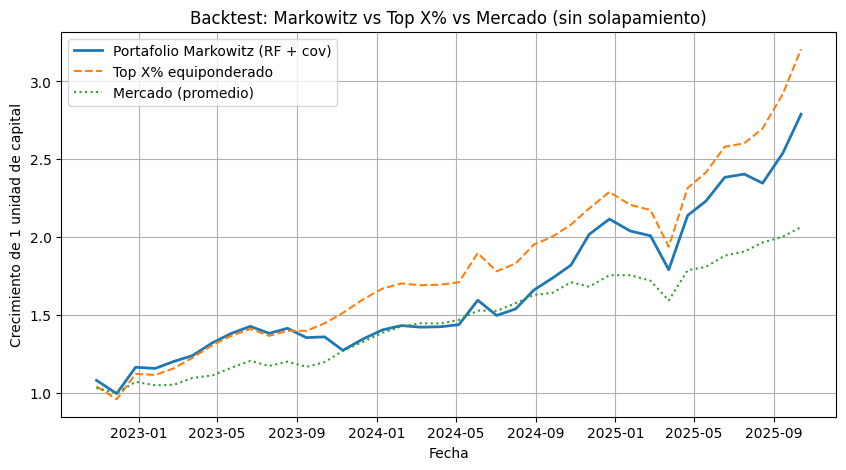

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df_mark_bt["Date"], df_mark_bt["cum_markowitz"], label="Portafolio Markowitz (RF + cov)", linewidth=2)
plt.plot(df_mark_bt["Date"], df_mark_bt["cum_equal_top"], label="Top X% equiponderado", linestyle="--")
plt.plot(df_mark_bt["Date"], df_mark_bt["cum_mkt"], label="Mercado (promedio)", linestyle=":")
plt.xlabel("Fecha")
plt.ylabel("Crecimiento de 1 unidad de capital")
plt.title("Backtest: Markowitz vs Top X% vs Mercado (sin solapamiento)")
plt.grid(True)
plt.legend()
plt.show()


# Metricas de riesgo 

In [ ]:
def compute_strategy_metrics(returns, horizon_days=20, name="strategy"):
    """
    Calcula métricas simples de riesgo–retorno para una estrategia
    cuyos rendimientos están definidos a un horizonte fijo (p.ej. 20 días).

    returns: Serie o array con los retornos por rebalanceo 
    horizon_days: tamaño del horizonte (5, 20, etc.)
    """
    rets = np.asarray(returns)
    rets = rets[~np.isnan(rets)]

    total_return = (1 + rets).prod() - 1

    periods_per_year = 252 / horizon_days
    mean_period = rets.mean()
    std_period = rets.std(ddof=1)

    # Retorno anualizado (aprox) y volatilidad anualizada
    annual_return = (1 + mean_period) ** periods_per_year - 1
    annual_vol = std_period * np.sqrt(periods_per_year) if std_period > 0 else 0.0

    sharpe = np.nan
    if annual_vol > 0:
        sharpe = annual_return / annual_vol

    # Máx. drawdown
    curve = (1 + rets).cumprod()
    running_max = np.maximum.accumulate(curve)
    drawdowns = curve / running_max - 1
    max_dd = drawdowns.min()  # valor negativo

    return {
        "strategy": name,
        "total_return": total_return,
        "annual_return": annual_return,
        "annual_vol": annual_vol,
        "sharpe": sharpe,
        "max_drawdown": max_dd,
    }

# Aplicamos a tus tres series del backtest
metrics = []
metrics.append(compute_strategy_metrics(df_mark_bt["port_markowitz"], horizon_days=horizon_days, name="Markowitz"))
metrics.append(compute_strategy_metrics(df_mark_bt["port_equal_top"], horizon_days=horizon_days, name="Top_Equal"))
metrics.append(compute_strategy_metrics(df_mark_bt["mkt_ret"],        horizon_days=horizon_days, name="Mercado"))

metrics_df = pd.DataFrame(metrics).set_index("strategy")
print("\n=== Métricas riesgo–retorno (horizonte {} días) ===".format(horizon_days))
print(metrics_df)


=== Métricas riesgo–retorno (horizonte 20 días) ===
           total_return  annual_return  annual_vol    sharpe  max_drawdown
strategy                                                                  
Markowitz      1.789734       0.438068    0.224847  1.948292     -0.153725
Top_Equal      2.206990       0.499935    0.204476  2.444952     -0.153725
Mercado        1.063777       0.280248    0.120484  2.326021     -0.092480


In [85]:
# Perfiles de riesgo que luego puedes mapear a la app
risk_profiles = {
    "conservador": {
        "top_frac": 0.10,    # invierte en el 10% mejor rankeado
        "lookback_days": 90, # usa más historia para covarianza
        "risk_aversion": 20.0,
    },
    "moderado": {
        "top_frac": 0.20,
        "lookback_days": 60,
        "risk_aversion": 10.0,
    },
    "agresivo": {
        "top_frac": 0.30,
        "lookback_days": 40,
        "risk_aversion": 5.0,
    },
}

def construir_portafolio_fecha(df_all, df_eval, profile="moderado",
                               fecha=None, horizon_col="y_20d"):
    """
    Construye un portafolio sugerido para una fecha dada usando:
    - ranking del RandomForest (y_pred_rf),
    - Markowitz long-only sobre el subconjunto top.

    df_all: panel completo con columnas [Date, Ticker, Return, ...]
    df_eval: df de test con columnas [Date, Ticker, y_pred_rf, y_real, ...]
    profile: 'conservador' | 'moderado' | 'agresivo'
    fecha: fecha de rebalanceo (si None, usa la última disponible)
    """

    cfg = risk_profiles[profile]
    top_frac      = cfg["top_frac"]
    lookback_days = cfg["lookback_days"]
    risk_aversion = cfg["risk_aversion"]

    df_all = df_all.copy()
    df_all["Date"] = pd.to_datetime(df_all["Date"])

    df_eval = df_eval.copy()
    df_eval["Date"] = pd.to_datetime(df_eval["Date"])

    # Si no se da fecha, usamos la más reciente del test
    if fecha is None:
        fecha = df_eval["Date"].max()

    grupo = df_eval[df_eval["Date"] == fecha].copy()
    if len(grupo) == 0:
        raise ValueError(f"No hay datos en df_eval para la fecha {fecha}")

    grupo = grupo.sort_values("y_pred_rf", ascending=False)

    # Top X% según el modelo
    k = max(3, int(len(grupo) * top_frac))
    top = grupo.head(k).copy()
    tickers_top = top["Ticker"].unique()

    # Historial de retornos para covarianza
    fecha_inicio_lb = fecha - pd.Timedelta(days=lookback_days)
    df_hist = df_all[
        (df_all["Date"] < fecha) &
        (df_all["Date"] >= fecha_inicio_lb) &
        (df_all["Ticker"].isin(tickers_top))
    ].copy()

    ret_mat = df_hist.pivot(index="Date", columns="Ticker", values="Return")
    min_non_na = int(lookback_days * 0.7)
    ret_mat = ret_mat.dropna(axis=1, thresh=min_non_na)

    if ret_mat.shape[1] < 3:
        # Muy pocos activos con historia sólida → equiponderado del top
        tickers_final = top["Ticker"].unique()
        w = np.full(len(tickers_final), 1.0 / len(tickers_final))
    else:
        tickers_final = ret_mat.columns
        Sigma = ret_mat.cov().values

        # mu: predicciones del modelo para estos tickers
        mu_vec = (
            top.set_index("Ticker")
               .reindex(tickers_final)["y_pred_rf"]
               .values
        )
        mu_mean = np.nanmean(mu_vec)
        mu_vec = np.where(np.isnan(mu_vec), mu_mean, mu_vec)

        w = markowitz_long_only(mu_vec, Sigma, risk_aversion=risk_aversion)

    # Armamos dataframe de portafolio sugerido
    scores = (
        top.set_index("Ticker")
           .reindex(tickers_final)["y_pred_rf"]
           .values
    )

    df_port = pd.DataFrame({
        "Ticker": tickers_final,
        "Weight": w,
        "Score_modelo": scores,
    })

    df_port = df_port.sort_values("Weight", ascending=False).reset_index(drop=True)

    return fecha, profile, df_port

In [ ]:
# Ejemplo: portafolio sugerido para la última fecha con perfil conservador 
fecha_rec, perfil, port_sugerido = construir_portafolio_fecha(
    df_all=df_all,
    df_eval=df_eval,
    profile="conservador",      # o 'agresivo', 'moderado'
    fecha=None,              # None = última fecha disponible
    horizon_col="y_20d",
)

print("Portafolio sugerido para la fecha:", fecha_rec.date(), " | Perfil:", perfil)
port_sugerido.head(20)

Portafolio sugerido para la fecha: 2025-10-20  | Perfil: conservador


,Ticker,Weight,Score_modelo
0,PGR,3.388162e-01,0.015728
1,GEV,1.462764e-01,0.020996
2,MU,1.200670e-01,0.022875
3,INTC,1.177943e-01,0.025331
4,COP,1.062043e-01,0.016943
5,LRCX,8.777906e-02,0.021222
6,PFE,5.497612e-02,0.016079
7,AMD,2.808663e-02,0.018020
8,BX,1.019150e-17,0.015758
9,ORCL,0.000000e+00,0.017866
